In [37]:
import os
import sys
import re
import numpy as np
import pandas as pd
import plotly.express as px
import scipy.stats as stats
from scipy.stats import pearsonr
from dash import html, dcc, Input, Output, Dash
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

sys.path.append(os.path.join(os.getcwd(), '..', '..', '..'))
from baseVR.base_functionality import init_import_paths
init_import_paths() 

from CustomLogger import CustomLogger as Logger
from analytics_processing import analytics

from analytics_processing.sessions_from_nas_parsing import sessionlist_fullfnames_from_args, fullfnames2snames
from dashsrc.plot_components.plots import plot_TrackFiringRate
from dashsrc.plot_components.plots import plot_unit_fr_stability


In [38]:
Logger().init_logger(None, None, logging_level="DEBUG")
animal_ids = [6]
paradigm = [1100]
session_range = [1,33]
session_ids = None
normalize = True
smooth = False
excl_session_names = ['2024-11-29_17-21_rYL006_P1100_LinearTrackStop_28min', '2025-01-21_18-49_rYL006_P1100_LinearTrackStop_30min', '2024-12-11_17-42_rYL006_P1100_LinearTrackStop_30min'] # ignore short sessions (10, 24,25)

session_dirs = sessionlist_fullfnames_from_args(paradigm, animal_ids, session_ids, excl_session_names=excl_session_names)[0]
session_names= fullfnames2snames(session_dirs)

2026-02-17 20:12:17,153|DEBUG|27560|sessions_from_nas_parsing|get_sessionlist_fullfnames
	Searching NAS for applicable sessions...
Searching NAS for applicable sessions...================================================================================

2026-02-17 20:12:17,153|DEBUG|27560|sessions_from_nas_parsing|get_sessionlist_fullfnames
	Searching NAS for applicable sessions...
2026-02-17 20:12:17,726|DEBUG|27560|sessions_from_nas_parsing|get_sessionlist_fullfnames
	Session 2024-11-29_17-21_rYL006_P1100_LinearTrackStop_28min.hdf5 excluded
Session 2024-11-29_17-21_rYL006_P1100_LinearTrackStop_28min.hdf5 excluded================================================================================

2026-02-17 20:12:17,726|DEBUG|27560|sessions_from_nas_parsing|get_sessionlist_fullfnames
	Session 2024-11-29_17-21_rYL006_P1100_LinearTrackStop_28min.hdf5 excluded
2026-02-17 20:12:17,981|DEBUG|27560|sessions_from_nas_parsing|get_sessionlist_fullfnames
	Session 2024-12-11_17-42_rYL006_P1100_Linea

In [39]:
fr = analytics.get_analytics('FiringRate40msHz', session_names=session_names)
fr_track = analytics.get_analytics('FiringRateTrackwiseHz', session_names=session_names)
# fr_z_scored  = analytics.get_analytics('FiringRate40msZ', session_names=session_names)
fr_z_all_sess = fr.apply(lambda unit_fr: ((unit_fr - unit_fr.mean()) / unit_fr.std()))
# behav = analytics.get_analytics('BehaviorTrackwise', session_names=session_names)
# behav.index = behav.index.droplevel(('animal_id', 'paradigm_id', 'entry_id'))

2026-02-17 20:12:18,845|DEBUG|27560|sessions_from_nas_parsing|sessionnames2fullfnames
	Inferring NAS paths for list of session names...
Inferring NAS paths for list of session names...================================================================================

2026-02-17 20:12:18,845|DEBUG|27560|sessions_from_nas_parsing|sessionnames2fullfnames
	Inferring NAS paths for list of session names...
2026-02-17 20:12:19,164|DEBUG|27560|sessions_from_nas_parsing|sessionlist_fullfnames_from_args
	Paradigm_ids: None, animal_ids: None, session_ids: None, from_date: None, to_date: None
	Merging 31 sessions

Paradigm_ids: None, animal_ids: None, session_ids: None, from_date: None, to_date: None
	Merging 31 sessions

2026-02-17 20:12:19,164|DEBUG|27560|sessions_from_nas_parsing|sessionlist_fullfnames_from_args
	Paradigm_ids: None, animal_ids: None, session_ids: None, from_date: None, to_date: None
	Merging 31 sessions

2026-02-17 20:12:19,166|DEBUG|27560|analytics|get_analytics
	Processing Firi

In [40]:
ensambles = analytics.get_analytics('ConcatenatedEnsambles40ms', session_names=session_names)
ens_data = analytics.get_analytics('TrackwiseEnsembleProj', session_names=session_names)
#ensamble_proj = analytics.get_analytics('ConcatenatedEnsambleProj40ms', session_names=session_names)#.drop("to_ephys_timestamp", axis=1)
# ensamble_proj.set_index(['session_id'], inplace = True)
ens_data = ens_data.set_index(['session_id', 'trial_id']).sort_index()

2026-02-17 20:12:40,037|DEBUG|27560|sessions_from_nas_parsing|sessionnames2fullfnames
	Inferring NAS paths for list of session names...
Inferring NAS paths for list of session names...================================================================================

Inferring NAS paths for list of session names...================================================================================

2026-02-17 20:12:40,058|DEBUG|27560|sessions_from_nas_parsing|sessionlist_fullfnames_from_args
	Paradigm_ids: None, animal_ids: None, session_ids: None, from_date: None, to_date: None
	Merging 31 sessions

Paradigm_ids: None, animal_ids: None, session_ids: None, from_date: None, to_date: None
	Merging 31 sessions

Paradigm_ids: None, animal_ids: None, session_ids: None, from_date: None, to_date: None
	Merging 31 sessions

2026-02-17 20:12:40,059|DEBUG|27560|analytics|get_analytics
	Processing ConcatenatedEnsambles40ms, for n=31 sessions
Processing ConcatenatedEnsambles40ms, for n=31 sessions======

/Volumes/large/BMI/VirtualReality/SpatialSequenceLearning/RUN_rYL006/rYL006_P1100/2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min/../../animal_analytics/ConcatenatedEnsambles40ms.parquet
/Volumes/large/BMI/VirtualReality/SpatialSequenceLearning/RUN_rYL006/rYL006_P1100/2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min/../../animal_analytics/TrackwiseEnsembleProj.parquet


2026-02-17 20:12:57,014|INFO|27560|analytics|get_analytics
	Loaded animal-level analytic `TrackwiseEnsembleProj` last modified on 2026-02-17T13:13:21.158725
Loaded animal-level analytic `TrackwiseEnsembleProj` last modified on 2026-02-17T13:13:21.158725================================================================================

Loaded animal-level analytic `TrackwiseEnsembleProj` last modified on 2026-02-17T13:13:21.158725================================================================================



In [41]:
neurons_ordered = abs(ensambles['Assembly012']).sort_values(ascending=True).index

fr_track_selected = fr_track[(fr_track['from_position_bin'] >= (-95)) & (fr_track['from_position_bin'] <= 10)] # cue zone
fr_track_selected = fr_track_selected[fr_track_selected['cue'] == 1] # cue
fr_track_selected = fr_track_selected[fr_track_selected['choice_R2'] == False] # outcome

session_ids_all = fr_track_selected.index.get_level_values("session_id").unique()
session_ids_all = pd.to_datetime(session_ids_all, format="%Y-%m-%d_%H-%M")

In [43]:
def mean_offdiag_corr(corr_df: pd.DataFrame) -> float:
    k = corr_df.shape[0]
    if k < 2:
        return np.nan
    iu = np.triu_indices(k, k=1)
    vals = corr_df.to_numpy()[iu]
    return float(np.nanmean(vals))


In [44]:
top_ns = [10, 20, 77]
session_ids_all = fr_track_selected.index.get_level_values("session_id").unique()
fr_used = fr_z_all_sess.copy()

# 2x2 layout: correlations on first row, firing rates on second row
fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=(
        "Pearson corr (unweighted)", "Pearson corr (weighted)",
        "Mean firing rate (unweighted)", "Mean firing rate (weighted)"
    ),
    shared_yaxes=False,
)

weights = ensambles["Assembly012"]
try:
    weights.index = [f"Unit{int(i)+1:04d}" for i in weights.index]  # align to FR column naming
except Exception as e:
    print(f"Error setting weights index: {e}")



# pearson correlations for single neurons weighted and unweightes
for top_n in top_ns:
    top_n_neurons = neurons_ordered[-top_n:]
    rows_unw, rows_w = [], []

    for session_id in session_ids_all:
        neuron_data_session = fr_used.xs(session_id, level=2)

        unit_cols = [
            c for c in neuron_data_session.columns
            if isinstance(c, str) and c.startswith("Unit")
        ]
        neuron_data_session = neuron_data_session[unit_cols]

        top_unit_cols = [
            f"Unit{i+1:04d}" for i in top_n_neurons
            if f"Unit{i+1:04d}" in neuron_data_session.columns
        ]

        neuron_data_top = neuron_data_session[top_unit_cols]

        corr_unw = neuron_data_top.corr(method="pearson")
        rows_unw.append((session_id, mean_offdiag_corr(corr_unw)))

        w = weights.loc[top_unit_cols]
        neuron_data_top_w = neuron_data_top.mul(w, axis=1)
        corr_w = neuron_data_top_w.corr(method="pearson")
        rows_w.append((session_id, mean_offdiag_corr(corr_w)))

    df_unw = pd.DataFrame(rows_unw, columns=["session_id", "avg_corr"])
    df_w = pd.DataFrame(rows_w, columns=["session_id", "avg_corr"])

    fig.add_trace(
        go.Scatter(
            x=df_unw["session_id"],
            y=df_unw["avg_corr"],
            mode="lines+markers",
            name=f"top {top_n}",
            legendgroup=f"top{top_n}",
        ),
        row=1,
        col=1,
    )

    fig.add_trace(
        go.Scatter(
            x=df_w["session_id"],
            y=df_w["avg_corr"],
            mode="lines+markers",
            name=f"top {top_n}",
            legendgroup=f"top{top_n}",
            showlegend=False,  # avoid duplicated legend entries
        ),
        row=1,
        col=2,
    )


# mean fr
fr_units = fr_used.loc[:, fr_used.columns.str.startswith("Unit")]
# fr_units = fr.loc[:, fr.columns.str.startswith("Unit")]
fr_units = fr_units[fr_units.index.get_level_values(2) != 10]

w_all = ensambles["Assembly012"].copy()
w_all = w_all.reindex(fr_units.columns)
fr_units_weighted = fr_units.mul(w_all, axis=1)

session_means_unweighted = (
    fr_units
    .groupby(level=2)
    .mean()
    .mean(axis=1)
)

session_means_weighted = (
    fr_units_weighted
    .groupby(level=2)
    .mean()
    .mean(axis=1)
)

fig.add_scatter(
    x=session_means_unweighted.index,
    y=session_means_unweighted.values,
    mode="lines+markers",
    name="Mean FR unweighted",
    row=2,
    col=1,
)

fig.add_scatter(
    x=session_means_weighted.index,
    y=session_means_weighted.values,
    mode="lines+markers",
    name="Mean FR weighted",
    row=2,
    col=2,
)


fig.update_layout(
    title="Session-wise Pearson correlations (top row) and mean firing rates (bottom row)",
    width=1200,
    height=800,
)

fig.update_xaxes(title_text="Session", row=1, col=1)
fig.update_xaxes(title_text="Session", row=1, col=2)
fig.update_xaxes(title_text="Session", row=2, col=1)
fig.update_xaxes(title_text="Session", row=2, col=2)

fig.update_yaxes(title_text="Avg pairwise Pearson r", row=1, col=1)
fig.update_yaxes(title_text="Avg pairwise Pearson r", row=1, col=2)
fig.update_yaxes(title_text="Mean firing rate (z-scored)", row=2, col=1)
fig.update_yaxes(title_text="Mean firing rate (z-scored)", row=2, col=2)

fig.update_yaxes(range=[-1, 1], row=1, col=1)
fig.update_yaxes(range=[-1, 1], row=1, col=2)

fig.show()

Error setting weights index: invalid literal for int() with base 10: 'Unit0001'


In [45]:
sessions = [16, ]
assembly_name = "Assembly012"
target = "rms_a"                 # "var_a" 
min_T = 200                      # minimum time bins after filtering
min_finite_frac_per_unit = 0.99  # keep units that are finite in >=99% of rows for that session
min_units = 10
renorm_weights = True

# inputs
# selecting only sessions 14 - 18


Z_df = fr_z_all_sess.copy()#.loc[fr.index.get_level_values("session_id").isin(sessions)]
unit_cols = [c for c in Z_df.columns if isinstance(c, str) and c.startswith("Unit")]
if not unit_cols:
    raise ValueError("No 'UnitXXXX' columns found in fr_z_scored.")

w_raw = ensambles[assembly_name].copy()
if not all(isinstance(i, str) and i.startswith("Unit") for i in w_raw.index):
    try:
        w_raw.index = [f"Unit{int(i)+1:04d}" for i in w_raw.index]
    except Exception as e:
        raise ValueError("Could not map weight index to UnitXXXX.") from e

# Use only units present in data
units_all = [u for u in w_raw.index if u in unit_cols]
if len(units_all) < 2:
    raise ValueError("Too few overlapping units between weights and fr_z_scored.")

Z_units = Z_df[units_all]

def iter_sessions(Z: pd.DataFrame):
    if isinstance(Z.index, pd.MultiIndex) and "session_id" in Z.index.names:
        for s in sorted(Z.index.get_level_values("session_id").unique()):
            yield s, Z.xs(s, level="session_id")
        return
    if Z.index.name == "session_id":
        for s in sorted(Z.index.unique()):
            yield s, Z.loc[s]
        return
    if "session_id" in Z.columns:
        for s, g in Z.groupby("session_id", sort=True):
            yield s, g.drop(columns=["session_id"])
        return
    raise ValueError("Cannot find session_id in fr_z_scored (neither index level nor column).")


# Per-session computation with column-wise filtering

rows = []
Sigma_by_session = {}
units_by_session = {}
w_by_session = {}

for s, Z_s in iter_sessions(Z_units):
    X = np.asarray(Z_s.values, dtype=float)  # shape (T, N_all)
    T_raw, N_all = X.shape

    if T_raw == 0:
        rows.append({"session_id": s, "T_raw": 0, "T_used": 0, "N_used": 0,
                     "mean_a": np.nan, "var_a": np.nan, "diag_var": np.nan, "offdiag_var": np.nan})
        Sigma_by_session[s] = None
        continue

    # keep units that are finite in most rows (per-session)
    finite_mask = np.isfinite(X)  # (T, N_all)
    finite_frac = finite_mask.mean(axis=0)  # (N_all,)
    keep_cols = finite_frac >= min_finite_frac_per_unit

    if keep_cols.sum() < min_units:
        rows.append({"session_id": s, "T_raw": T_raw, "T_used": 0, "N_used": int(keep_cols.sum()),
                     "mean_a": np.nan, "var_a": np.nan, "diag_var": np.nan, "offdiag_var": np.nan})
        Sigma_by_session[s] = None
        continue

    kept_units = list(np.array(units_all)[keep_cols])

    # subset X and drop rows that still have any NaN/inf (rare after column filter)
    Xk = X[:, keep_cols]
    ok_rows = np.isfinite(Xk).all(axis=1)
    Xk = Xk[ok_rows, :]
    T_used, N_used = Xk.shape

    if T_used < min_T or N_used < min_units:
        rows.append({"session_id": s, "T_raw": T_raw, "T_used": T_used, "N_used": N_used,
                     "mean_a": np.nan, "var_a": np.nan, "diag_var": np.nan, "offdiag_var": np.nan})
        Sigma_by_session[s] = None
        continue

    # align weights to kept units
    w_s = w_raw.loc[kept_units].astype(float).values

    # Optional: renormalize weights so that comparisons across sessions are not dominated by changing N_used
    if renorm_weights:
        norm = np.linalg.norm(w_s)
        if norm > 0:
            w_s = w_s / norm

    # assembly activation and covariance decomposition
    a = Xk @ w_s
    mean_a = float(np.mean(a))

    Sigma = np.cov(Xk, rowvar=False, bias=False)
    var_a = float(w_s.T @ Sigma @ w_s)
    diag_var = float(np.sum((w_s ** 2) * np.diag(Sigma)))
    offdiag_var = float(var_a - diag_var)

    rows.append({"session_id": s, "T_raw": T_raw, "T_used": T_used, "N_used": N_used,
                 "mean_a": mean_a, "var_a": var_a, "diag_var": diag_var, "offdiag_var": offdiag_var})

    Sigma_by_session[s] = Sigma
    units_by_session[s] = kept_units
    w_by_session[s] = w_s

metrics = pd.DataFrame(rows).set_index("session_id").sort_index()
metrics["rms_a"] = np.sqrt(metrics["var_a"])
metrics["diag_frac"] = metrics["diag_var"] / metrics["var_a"]
metrics["offdiag_frac"] = metrics["offdiag_var"] / metrics["var_a"]

display(metrics)

# Find largest drop safely
valid = metrics[target].dropna()
if valid.shape[0] < 2:
    raise ValueError(
        f"Not enough valid sessions for target={target}. "
        f"Valid sessions={valid.shape[0]}. "
        f"Try lowering min_T, lowering min_finite_frac_per_unit, or check why many units are NaN."
    )

delta = valid.diff().dropna()
drop_session = delta.idxmin()
prev_session = valid.index[valid.index.get_loc(drop_session) - 1]

print(f"\nLargest drop in {target}: session {prev_session} -> {drop_session} (Δ={delta.loc[drop_session]:.6g})")
print(f"Session sizes: prev(T={metrics.loc[prev_session,'T_used']}, N={metrics.loc[prev_session,'N_used']}), "
      f"drop(T={metrics.loc[drop_session,'T_used']}, N={metrics.loc[drop_session,'N_used']})")


# Attribution for that drop (only on common kept units)
U_prev = units_by_session[prev_session]
U_drop = units_by_session[drop_session]
common_units = sorted(set(U_prev).intersection(U_drop))

if len(common_units) < min_units:
    raise ValueError(
        f"Too few common units between prev and drop sessions for attribution: {len(common_units)}. "
        f"This indicates strong session-to-session changes in which units are finite."
    )

# Recompute Sigma on common units only (consistent dimensionality)
def get_X_session_common(s, common_units):
    Z_s = next(g for sid, g in iter_sessions(Z_units) if sid == s)  # session df with all units_all
    X = Z_s[common_units].to_numpy(dtype=float)
    ok = np.isfinite(X).all(axis=1)
    return X[ok, :]

X_prev = get_X_session_common(prev_session, common_units)
X_drop = get_X_session_common(drop_session, common_units)

if X_prev.shape[0] < min_T or X_drop.shape[0] < min_T:
    raise ValueError("After restricting to common units, not enough finite rows remain for covariance.")

Sigma_prev = np.cov(X_prev, rowvar=False, bias=False)
Sigma_drop = np.cov(X_drop, rowvar=False, bias=False)
dSigma = Sigma_drop - Sigma_prev

# weights restricted to common units (and optionally renormalized)
w_common = w_raw.loc[common_units].astype(float).values
if renorm_weights:
    norm = np.linalg.norm(w_common)
    if norm > 0:
        w_common = w_common / norm

dVar_total = float(w_common.T @ dSigma @ w_common)
dVar_diag  = float(np.sum((w_common ** 2) * np.diag(dSigma)))
dVar_off   = float(dVar_total - dVar_diag)

print(f"\nAttribution on common units (N={len(common_units)}):")
print(f" delta Var(a) total:   {dVar_total:.6g}")
print(f"  diagonal part: {dVar_diag:.6g}")
print(f"  offdiag part:  {dVar_off:.6g}")

# unit and pair driver scores
unit_driver = pd.Series((w_common ** 2) * np.diag(dSigma), index=common_units).sort_values()

C = np.outer(w_common, w_common) * dSigma
np.fill_diagonal(C, 0.0)

pair_rows = []
N = len(common_units)
for i in range(N):
    for j in range(i + 1, N):
        pair_rows.append((common_units[i], common_units[j], C[i, j]))

pair_driver = pd.DataFrame(pair_rows, columns=["unit_i", "unit_j", "pair_score"]).sort_values("pair_score")

print("\nTop unit-level diagonal drivers (most negative):")
display(unit_driver.head(15).to_frame("d_i = w_i^2 * Sigma_ii"))

print("\nTop pair-level off diagonal drivers (most negative):")
display(pair_driver.head(20))


,T_raw,T_used,N_used,mean_a,var_a,diag_var,offdiag_var,rms_a,diag_frac,offdiag_frac
session_id,,,,,,,,,,
2024-11-14_16-40,32200,32200,77,-0.628982,0.872852,0.735600,0.137252,0.934265,0.842755,0.157245
2024-11-15_15-48,53592,53592,77,-0.977276,1.266279,1.027443,0.238836,1.125290,0.811388,0.188612
2024-11-20_17-46,33834,33834,77,-0.627301,1.297376,0.899514,0.397862,1.139024,0.693334,0.306666
2024-11-21_17-22,38805,38805,77,-0.697124,1.083639,0.782896,0.300743,1.040980,0.722469,0.277531
2024-11-25_16-25,27459,27459,77,-0.470693,1.193339,0.835261,0.358079,1.092401,0.699936,0.300064
2024-11-26_16-39,38213,38213,77,-0.830813,1.142871,0.810340,0.332531,1.069051,0.709039,0.290961
2024-11-28_17-41,46119,46119,77,-1.095048,1.209645,0.899296,0.310349,1.099839,0.743438,0.256562
2024-12-02_16-09,42833,42833,77,-1.145664,1.459417,1.079687,0.379730,1.208063,0.739807,0.260193
2024-12-03_16-23,45100,45100,77,-1.600169,1.642669,1.185702,0.456967,1.281667,0.721814,0.278186



Largest drop in rms_a: session 2025-01-22_17-51 -> 2025-01-23_16-48 (Δ=-0.315413)
Session sizes: prev(T=8027, N=77), drop(T=63199, N=77)

Attribution on common units (N=77):
 delta Var(a) total:   -0.71768
  diagonal part: -0.307904
  offdiag part:  -0.409776

Top unit-level diagonal drivers (most negative):


,d_i = w_i^2 * Sigma_ii
Unit0023,-0.150040
Unit0073,-0.059665
Unit0052,-0.028583
Unit0045,-0.019817
Unit0075,-0.018526
Unit0037,-0.016445
Unit0039,-0.014175
Unit0065,-0.013810
Unit0046,-0.012143
Unit0025,-0.011269



Top pair-level off diagonal drivers (most negative):


,unit_i,unit_j,pair_score
1468,Unit0023,Unit0051,-0.028580
1469,Unit0023,Unit0052,-0.014274
2141,Unit0037,Unit0073,-0.011263
2601,Unit0052,Unit0053,-0.009438
1463,Unit0023,Unit0046,-0.008574
1470,Unit0023,Unit0053,-0.008150
2404,Unit0045,Unit0052,-0.008105
2435,Unit0046,Unit0052,-0.007950
2417,Unit0045,Unit0065,-0.007799
1483,Unit0023,Unit0066,-0.006708


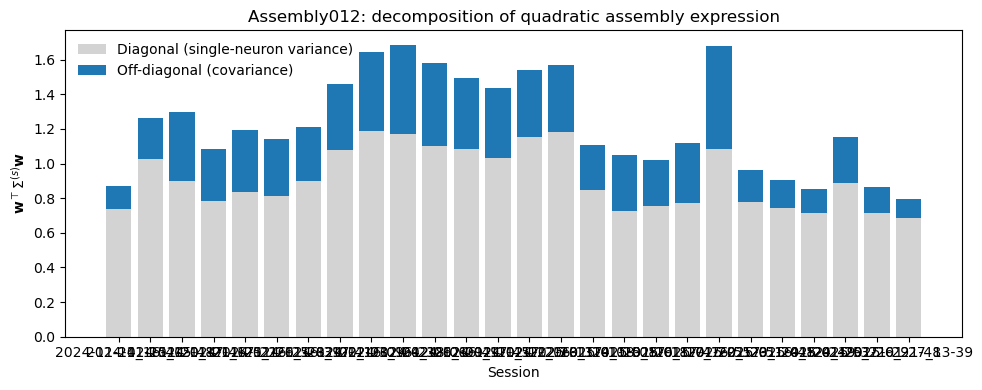

In [46]:
# plotting mean activity
fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(metrics.index, metrics["diag_var"], label="Diagonal (single-neuron variance)", color="lightgray")
ax.bar(
    metrics.index,
    metrics["offdiag_var"],
    bottom=metrics["diag_var"],
    label="Off-diagonal (covariance)",
    color="tab:blue"
)

ax.set_ylabel(r"$\mathbf{w}^\top \Sigma^{(s)} \mathbf{w}$")
ax.set_xlabel("Session")
ax.set_title(f"{assembly_name}: decomposition of quadratic assembly expression")
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

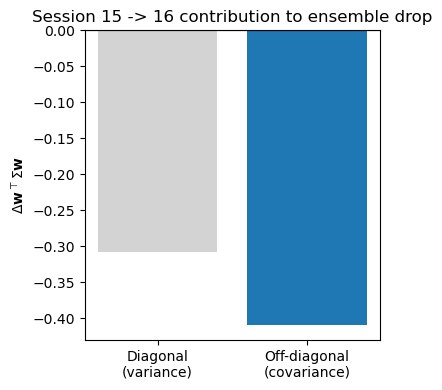

In [47]:
fig, ax = plt.subplots(figsize=(4, 4))

vals = [dVar_diag, dVar_off]
labels = ["Diagonal\n(variance)", "Off-diagonal\n(covariance)"]
colors = ["lightgray", "tab:blue"]

ax.bar(labels, vals, color=colors)
ax.axhline(0, color="black", linewidth=0.8)

ax.set_ylabel(r"$\Delta \mathbf{w}^\top \Sigma \mathbf{w}$")
ax.set_title("Session 15 -> 16 contribution to ensemble drop")

plt.tight_layout()
plt.show()


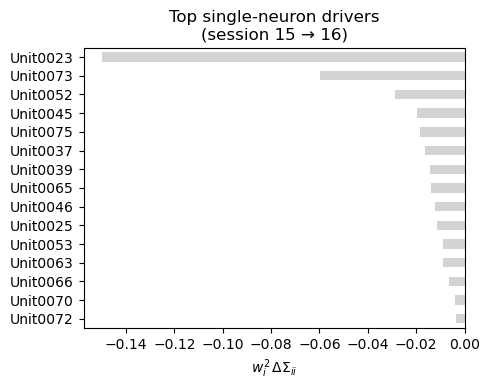

In [48]:
top_units = unit_driver.head(15)

fig, ax = plt.subplots(figsize=(5, 4))
top_units[::-1].plot(kind="barh", ax=ax, color="lightgray")

ax.set_xlabel(r"$w_i^2 \, \Delta \Sigma_{ii}$")
ax.set_title("Top single-neuron drivers\n(session 15 → 16)")

plt.tight_layout()
plt.show()


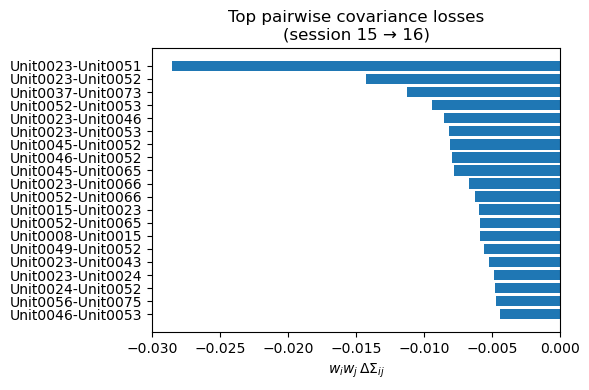

In [49]:
top_pairs = pair_driver.head(20)

fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(
    range(len(top_pairs)),
    top_pairs["pair_score"],
    color="tab:blue"
)
ax.set_yticks(range(len(top_pairs)))
ax.set_yticklabels(
    [f"{u}-{v}" for u, v in zip(top_pairs["unit_i"], top_pairs["unit_j"])]
)

ax.set_xlabel(r"$w_i w_j \, \Delta \Sigma_{ij}$")
ax.set_title("Top pairwise covariance losses\n(session 15 → 16)")

ax.invert_yaxis()

plt.tight_layout()
plt.show()


In [50]:
fr.index.get_level_values("session_id").unique()

Index(['2024-11-14_16-40', '2024-11-15_15-48', '2024-11-20_17-46',
       '2024-11-21_17-22', '2024-11-25_16-25', '2024-11-26_16-39',
       '2024-11-28_17-41', '2024-12-02_16-09', '2024-12-03_16-23',
       '2024-12-04_18-06', '2024-12-06_16-49', '2024-12-09_17-45',
       '2024-12-10_17-20', '2024-12-12_16-13', '2024-12-13_17-10',
       '2025-01-14_18-08', '2025-01-15_17-18', '2025-01-16_17-47',
       '2025-01-17_16-55', '2025-01-22_17-51', '2025-01-23_16-48',
       '2025-01-24_12-24', '2025-01-24_19-37', '2025-01-25_21-29',
       '2025-01-26_21-48', '2025-01-27_13-39'],
      dtype='object', name='session_id')

In [51]:
# Decompose mean projection change for every consecutive session pair
valid_sessions = list(metrics[target].dropna().sort_index().index)

transition_unit_tables = []
transition_summary_rows = []
transition_pair_data = {}
transition_sep = "->"

for s_prev, s_next in zip(valid_sessions[:-1], valid_sessions[1:]):
    transition_label = f"{s_prev}{transition_sep}{s_next}"

    U_prev = units_by_session[s_prev]
    U_next = units_by_session[s_next]
    common_units = sorted(set(U_prev).intersection(U_next))

    X_prev = get_X_session_common(s_prev, common_units)
    X_next = get_X_session_common(s_next, common_units)

    w_common = w_raw.loc[common_units].astype(float).values
    if renorm_weights:
        nrm = np.linalg.norm(w_common)
        if nrm > 0:
            w_common = w_common / nrm

    w_series = pd.Series(w_common, index=common_units, name="w")
    mu_prev_units = pd.Series(X_prev.mean(axis=0), index=common_units, name="mu_prev")
    mu_next_units = pd.Series(X_next.mean(axis=0), index=common_units, name="mu_next")
    dmu_units = (mu_next_units - mu_prev_units).rename("dmu")
    contrib = (w_series * dmu_units).rename("w*dmu")

    y_prev = X_prev @ w_common
    y_next = X_next @ w_common
    dmu_y = float(y_next.mean() - y_prev.mean())
    sum_w_dmu = float(contrib.sum())

    transition_summary_rows.append(
        {
            "transition": transition_label,
            "session_prev": s_prev,
            "session_next": s_next,
            "n_common_units": len(common_units),
            "T_prev_common": int(X_prev.shape[0]),
            "T_next_common": int(X_next.shape[0]),
            "dmu_y": dmu_y,
            "sum_w_dmu": sum_w_dmu,
            "abs_err_check": abs(dmu_y - sum_w_dmu),
        }
    )

    unit_table = pd.concat([mu_prev_units, mu_next_units, dmu_units, w_series, contrib], axis=1).reset_index()
    unit_table = unit_table.rename(columns={"index": "unit"})
    unit_table["transition"] = transition_label
    unit_table["session_prev"] = s_prev
    unit_table["session_next"] = s_next
    transition_unit_tables.append(unit_table)

    transition_pair_data[transition_label] = {
        "session_prev": s_prev,
        "session_next": s_next,
        "y_prev": y_prev,
        "y_next": y_next,
    }
transition_unit_df = pd.concat(transition_unit_tables, ignore_index=True)
transition_summary_df = (
    pd.DataFrame(transition_summary_rows)
    .set_index("transition")
    .sort_values(["session_prev", "session_next"])
)

print("Per-transition projection-mean decomposition (all consecutive sessions):")
display(transition_summary_df)

# Each neuron's mean firing-rate change across consecutive transitions
dmu_by_unit_transition = transition_unit_df.pivot(index="unit", columns="transition", values="dmu")
display(dmu_by_unit_transition)

# Optional quick visualization: top units by average |\u0394mu| across transitions
top_n_units = min(30, dmu_by_unit_transition.shape[0])
units_rank = dmu_by_unit_transition.abs().mean(axis=1).sort_values(ascending=False)
top_units = units_rank.head(top_n_units).index
heatmap_data = dmu_by_unit_transition.loc[top_units].fillna(0.0)

vmax = np.nanmax(np.abs(heatmap_data.to_numpy()))
if vmax == 0:
    vmax = 1.0

x_transition_labels = [
    f"{str(c).split(transition_sep)[0].split('_')[0]}{transition_sep}{str(c).split(transition_sep)[1].split('_')[0]}"
    for c in heatmap_data.columns
]

fig = px.imshow(
    heatmap_data.to_numpy(),
    x=x_transition_labels,
    y=heatmap_data.index,
    color_continuous_scale="RdBu_r",
    zmin=-vmax,
    zmax=vmax,
    aspect="auto",
    labels={"x": "Session transition", "y": "Neuron", "color": "∆µ"},
)

fig.update_layout(
    title="Per-neuron mean firing-rate change ∆µ across consecutive sessions",
    # width=max(800, int(120 * heatmap_data.shape[1])),
    height=max(600, int(25 * heatmap_data.shape[0])),
)
fig.update_xaxes(tickangle=-45, side="bottom")
fig.show()

Per-transition projection-mean decomposition (all consecutive sessions):


,session_prev,session_next,n_common_units,T_prev_common,T_next_common,dmu_y,sum_w_dmu,abs_err_check
transition,,,,,,,,
2024-11-14_16-40->2024-11-15_15-48,2024-11-14_16-40,2024-11-15_15-48,77,32200,53592,-0.348294,-0.348294,1.466050e-13
2024-11-15_15-48->2024-11-20_17-46,2024-11-15_15-48,2024-11-20_17-46,77,53592,33834,0.349974,0.349974,2.613465e-13
2024-11-20_17-46->2024-11-21_17-22,2024-11-20_17-46,2024-11-21_17-22,77,33834,38805,-0.069823,-0.069823,1.726536e-13
2024-11-21_17-22->2024-11-25_16-25,2024-11-21_17-22,2024-11-25_16-25,77,38805,27459,0.226431,0.226431,2.725598e-13
2024-11-25_16-25->2024-11-26_16-39,2024-11-25_16-25,2024-11-26_16-39,77,27459,38213,-0.360120,-0.360120,1.612599e-13
2024-11-26_16-39->2024-11-28_17-41,2024-11-26_16-39,2024-11-28_17-41,77,38213,46119,-0.264236,-0.264236,3.980150e-14
2024-11-28_17-41->2024-12-02_16-09,2024-11-28_17-41,2024-12-02_16-09,77,46119,42833,-0.050616,-0.050616,5.417194e-14
2024-12-02_16-09->2024-12-03_16-23,2024-12-02_16-09,2024-12-03_16-23,77,42833,45100,-0.454504,-0.454504,1.557643e-13
2024-12-03_16-23->2024-12-04_18-06,2024-12-03_16-23,2024-12-04_18-06,77,45100,45795,-0.104284,-0.104284,1.456751e-13


transition,2024-11-14_16-40->2024-11-15_15-48,2024-11-15_15-48->2024-11-20_17-46,2024-11-20_17-46->2024-11-21_17-22,2024-11-21_17-22->2024-11-25_16-25,2024-11-25_16-25->2024-11-26_16-39,2024-11-26_16-39->2024-11-28_17-41,2024-11-28_17-41->2024-12-02_16-09,2024-12-02_16-09->2024-12-03_16-23,2024-12-03_16-23->2024-12-04_18-06,2024-12-04_18-06->2024-12-06_16-49,...,2025-01-14_18-08->2025-01-15_17-18,2025-01-15_17-18->2025-01-16_17-47,2025-01-16_17-47->2025-01-17_16-55,2025-01-17_16-55->2025-01-22_17-51,2025-01-22_17-51->2025-01-23_16-48,2025-01-23_16-48->2025-01-24_12-24,2025-01-24_12-24->2025-01-24_19-37,2025-01-24_19-37->2025-01-25_21-29,2025-01-25_21-29->2025-01-26_21-48,2025-01-26_21-48->2025-01-27_13-39
unit,,,,,,,,,,,,,,,,,,,,,
Unit0001,-0.231273,-0.032155,0.002167,-0.062584,0.000602,0.000267,0.050295,-0.052724,0.020877,-0.013723,...,-0.213498,-0.002978,-0.009754,0.006729,0.339634,-0.005563,-0.065496,0.386004,-0.649070,-2.100787e-02
Unit0002,0.061392,0.510264,-0.174813,-0.077372,0.063815,0.021135,-0.189735,0.141889,-0.061478,0.065028,...,0.000137,-0.018687,0.010265,0.076002,-0.075393,-0.067035,0.037044,0.231059,-0.221913,9.037713e-02
Unit0003,-0.017589,-0.055094,-0.021355,0.010991,0.010131,0.085879,0.194724,-0.006755,-0.120386,-0.097116,...,-0.460282,-0.005172,0.000404,-0.017975,0.028764,0.022450,-0.043294,-0.015246,-0.001233,6.231127e-14
Unit0004,0.003150,0.002791,-0.005591,-0.002773,0.005651,-0.004153,0.002145,-0.001295,0.007193,-0.005437,...,0.015751,-0.026522,-0.004977,0.087957,-0.020334,0.085657,-0.107140,0.335376,-0.265195,-3.782941e-02
Unit0005,0.026781,-0.022199,-0.064566,-0.045886,0.030607,-0.006969,0.140668,-0.138867,0.027785,-0.027423,...,-0.004781,0.001607,-0.003525,0.040324,-0.025382,-0.037319,0.007608,0.281409,-0.216425,-6.393298e-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Unit0073,0.334780,-0.436833,-0.008483,0.020618,-0.022097,0.006305,0.016260,-0.005871,-0.006692,0.013363,...,-0.000362,0.005619,-0.011771,0.608312,-0.565460,0.184987,-0.097785,0.235179,-0.115964,-2.049559e-01
Unit0074,0.053899,0.000569,-0.133989,-0.092509,0.127835,-0.121360,0.018129,-0.038669,-0.000062,0.022784,...,0.218937,-0.007117,-0.057428,0.814861,-0.040812,-0.245454,0.537274,-0.043970,0.441329,-5.524474e-01
Unit0075,0.003778,0.129819,-0.065689,0.000752,0.025031,-0.063564,0.034762,0.028253,0.019015,0.021592,...,0.217464,0.136018,0.037505,-0.412696,0.066069,-0.178738,0.125342,0.206439,-0.315710,-3.173183e-01


In [72]:
# Weighted version: per-neuron weighted change w_i * Δmu_i across consecutive sessions
weighted_by_unit_transition = transition_unit_df.pivot(index="unit", columns="transition", values="w*dmu")

top_n_units_w = min(30, weighted_by_unit_transition.shape[0])
units_rank_w = weighted_by_unit_transition.abs().mean(axis=1).sort_values(ascending=False)
top_units_w = units_rank_w.head(top_n_units_w).index
weighted_heatmap_data = weighted_by_unit_transition.loc[top_units_w].fillna(0.0)

vmax_w = np.nanmax(np.abs(weighted_heatmap_data.to_numpy()))
if vmax_w == 0:
    vmax_w = 1.0

transition_sep = "->"

x_transition_labels_w = [
    f"{str(c).split(transition_sep)[0].split('_')[0]}{transition_sep}{str(c).split(transition_sep)[1].split('_')[0]}"
    for c in weighted_heatmap_data.columns
]

fig_w = px.imshow(
    weighted_heatmap_data.to_numpy(),
    x=x_transition_labels_w,
    y=weighted_heatmap_data.index,
    color_continuous_scale="RdBu_r",
    zmin=-vmax_w,
    zmax=vmax_w,
    aspect="auto",
    labels={"x": "Session transition", "y": "Neuron", "color": "∆µ "},
)

fig_w.update_layout(
    title="Per-neuron (weighted) mean firing-rate change ∆µ across consecutive sessions",
    #width=max(800, int(120 * weighted_heatmap_data.shape[1])),
    height=max(600, int(15 * weighted_heatmap_data.shape[0])),
)
fig_w.update_xaxes(tickangle=-45, side="bottom")
fig_w.show()


In [80]:
# Same weighted heatmap, but neurons ordered by |Assembly012| weight in `ensambles`
assembly_col = "Assembly012"
top_k = 20

if "weighted_by_unit_transition" not in globals():
    weighted_by_unit_transition = transition_unit_df.pivot(index="unit", columns="transition", values="w*dmu")

if "ensambles" not in globals():
    raise RuntimeError("`ensambles` is not defined. Run the ensemble-loading cell first.")
if assembly_col not in ensambles.columns:
    raise KeyError(f"{assembly_col} not found in ensambles.")

w_assembly = ensambles[assembly_col].dropna().astype(float).copy()
if not all(isinstance(i, str) and i.startswith("Unit") for i in w_assembly.index):
    try:
        w_assembly.index = [f"Unit{int(i)+1:04d}" for i in w_assembly.index]
    except Exception:
        w_assembly.index = w_assembly.index.astype(str)

neurons_by_abs_weight = w_assembly.abs().sort_values(ascending=False).index
neurons_present = [u for u in neurons_by_abs_weight if u in weighted_by_unit_transition.index][:top_k]

if len(neurons_present) == 0:
    raise RuntimeError("No overlap between Assembly012 units and weighted transition units.")

weighted_heatmap_absw_order = weighted_by_unit_transition.loc[neurons_present].fillna(0.0)

vmax_absw = np.nanmax(np.abs(weighted_heatmap_absw_order.to_numpy()))
if vmax_absw == 0:
    vmax_absw = 1.0

transition_sep = "->"
x_transition_labels_absw = [
    f"{str(c).split(transition_sep)[0].split('_')[0]}{transition_sep}{str(c).split(transition_sep)[1].split('_')[0]}"
    for c in weighted_heatmap_absw_order.columns
]

fig_w_absorder = px.imshow(
    weighted_heatmap_absw_order.to_numpy(),
    x=x_transition_labels_absw,
    y=weighted_heatmap_absw_order.index,
    color_continuous_scale="RdBu_r",
    zmin=-vmax_absw,
    zmax=vmax_absw,
    aspect="auto",
    labels={"x": "Session transition", "y": "Neuron (top 20 by |Assembly012 weight|)", "color": "w*∆µ"},
)

fig_w_absorder.update_layout(
    title="Per-neuron weighted change (w*∆µ), top 20 neurons by |Assembly012 weight|",
    height=max(550, int(14 * weighted_heatmap_absw_order.shape[0])),
)
fig_w_absorder.update_xaxes(tickangle=-45, side="bottom")
fig_w_absorder.show()


In [53]:
quad_rows = []
for transition_label, pair in transition_pair_data.items():
    y_prev = pair["y_prev"]
    y_next = pair["y_next"]

    mu_prev = float(y_prev.mean())
    mu_next = float(y_next.mean())
    var_prev = float(y_prev.var(ddof=1))
    var_next = float(y_next.var(ddof=1))

    Ey2_prev = float((y_prev**2).mean())
    Ey2_next = float((y_next**2).mean())

    dEy2 = Ey2_next - Ey2_prev
    dVar = var_next - var_prev
    dMu2 = mu_next**2 - mu_prev**2

    quad_rows.append(
        {
            "transition": transition_label,
            "session_prev": pair["session_prev"],
            "session_next": pair["session_next"],
            "dE_y2": dEy2,
            "dVar_y": dVar,
            "dmu_y2": dMu2,
            "sum_check": dVar + dMu2,
            "abs_err_check": abs(dEy2 - (dVar + dMu2)),
        }
    )

quad_decomp_df = (
    pd.DataFrame(quad_rows)
    .set_index("transition")
    .loc[transition_summary_df.index]
)

print("Mean quadratic activity decomposition (all consecutive transitions):")
display(quad_decomp_df)


Mean quadratic activity decomposition (all consecutive transitions):


,session_prev,session_next,dE_y2,dVar_y,dmu_y2,sum_check,abs_err_check
transition,,,,,,,
2024-11-14_16-40->2024-11-15_15-48,2024-11-14_16-40,2024-11-15_15-48,0.952880,0.393427,0.559450,0.952876,3.479075e-06
2024-11-15_15-48->2024-11-20_17-46,2024-11-15_15-48,2024-11-20_17-46,-0.530478,0.031097,-0.561561,-0.530464,1.471720e-05
2024-11-20_17-46->2024-11-21_17-22,2024-11-20_17-46,2024-11-21_17-22,-0.121251,-0.213737,0.092475,-0.121261,1.042008e-05
2024-11-21_17-22->2024-11-25_16-25,2024-11-21_17-22,2024-11-25_16-25,-0.154746,0.109700,-0.264430,-0.154731,1.553369e-05
2024-11-25_16-25->2024-11-26_16-39,2024-11-25_16-25,2024-11-26_16-39,0.418243,-0.050468,0.468698,0.418229,1.355104e-05
2024-11-26_16-39->2024-11-28_17-41,2024-11-26_16-39,2024-11-28_17-41,0.575659,0.066774,0.508882,0.575655,3.679136e-06
2024-11-28_17-41->2024-12-02_16-09,2024-11-28_17-41,2024-12-02_16-09,0.363181,0.249772,0.113416,0.363189,7.843490e-06
2024-12-02_16-09->2024-12-03_16-23,2024-12-02_16-09,2024-12-03_16-23,1.431242,0.183252,1.247992,1.431244,2.350557e-06
2024-12-03_16-23->2024-12-04_18-06,2024-12-03_16-23,2024-12-04_18-06,0.387557,0.042939,0.344619,0.387557,3.848608e-07


In [54]:
# calculate std for all UNIt columns in fr and calculate average
avg_std = []
for col in fr.columns:
    if isinstance(col, str) and col.startswith('Unit'):
        # print(f"{col}: {fr[col].std()}")
        avg_std.append(fr[col].std())
average_std = np.mean(avg_std)

# means of neuron frs
means = []
for col in fr.columns: 
    if isinstance(col, str) and col.startswith('Unit'):
        print(f"{col}: {fr[col].mean()}")
        means.append(fr[col].mean())

print(min(means))
print(f'average std {avg_std}')

Unit0001: 0.8584905218304051
Unit0002: 3.3115018868867616
Unit0003: 0.1875952815335016
Unit0004: 0.3572081261090146
Unit0005: 0.4301726938744908
Unit0006: 0.5755356071776673
Unit0007: 5.72706448529228
Unit0008: 2.6902975283033013
Unit0009: 0.13095353385149827
Unit0010: 0.37888076999975007
Unit0011: 0.05556787793966961
Unit0012: 2.9402553545097843
Unit0013: 0.06060530327643516
Unit0014: 0.0324894409316972
Unit0015: 28.157606590358135
Unit0016: 5.134288387524054
Unit0017: 2.8912087946417415
Unit0018: 0.029131157373853498
Unit0019: 1.9529590383125484
Unit0020: 2.8533695299027815
Unit0021: 3.538322701372054
Unit0022: 8.05115290655537
Unit0023: 4.625820826981231
Unit0024: 23.351629470422115
Unit0025: 9.63475932821833
Unit0026: 2.4066592419963513
Unit0027: 5.427122903806263
Unit0028: 0.9912598717916677
Unit0029: 14.07202815335016
Unit0030: 0.8565185064853923
Unit0031: 3.040047140929198
Unit0032: 2.4239583073001274
Unit0033: 9.210912703371404
Unit0034: 5.6232115187564045
Unit0035: 6.049479231

In [55]:
sessions = [16, ]
assembly_name = "Assembly012"
target = "rms_a"                 # "var_a" 
min_T = 200
min_finite_frac_per_unit = 0.99  # keep units that are finite in >=99% of rows for that session
min_units = 10
renorm_weights = True


Z_df = fr_z_all_sess.copy()#.loc[fr.index.get_level_values("session_id").isin(sessions)]
unit_cols = [c for c in Z_df.columns if isinstance(c, str) and c.startswith("Unit")]

w_raw = ensambles[assembly_name].copy()
if not all(isinstance(i, str) and i.startswith("Unit") for i in w_raw.index):
    try:
        w_raw.index = [f"Unit{int(i)+1:04d}" for i in w_raw.index]
    except Exception as e:
        raise ValueError("Could not map weight index to UnitXXXX.") from e

# Use only units present in data
units_all = [u for u in w_raw.index if u in unit_cols]
if len(units_all) < 2:
    raise ValueError("Too few overlapping units between weights and fr_z_scored.")

Z_units = Z_df[units_all]

def iter_sessions(Z: pd.DataFrame):
    if isinstance(Z.index, pd.MultiIndex) and "session_id" in Z.index.names:
        for s in sorted(Z.index.get_level_values("session_id").unique()):
            yield s, Z.xs(s, level="session_id")
        return
    if Z.index.name == "session_id":
        for s in sorted(Z.index.unique()):
            yield s, Z.loc[s]
        return
    if "session_id" in Z.columns:
        for s, g in Z.groupby("session_id", sort=True):
            yield s, g.drop(columns=["session_id"])
        return
    raise ValueError("Cannot find session_id in fr_z_scored (neither index level nor column).")


# Per-session computation with column-wise filtering

rows = []
Sigma_by_session = {}
units_by_session = {}
w_by_session = {}

for s, Z_s in iter_sessions(Z_units):
    X = np.asarray(Z_s.values, dtype=float)  # shape (T, N_all)
    T_raw, N_all = X.shape

    if T_raw == 0:
        rows.append({"session_id": s, "T_raw": 0, "T_used": 0, "N_used": 0,
                     "mean_a": np.nan, "var_a": np.nan, "diag_var": np.nan, "offdiag_var": np.nan})
        Sigma_by_session[s] = None
        continue

    # keep units that are finite in most rows (per-session)
    finite_mask = np.isfinite(X)  # (T, N_all)
    finite_frac = finite_mask.mean(axis=0)  # (N_all,)
    keep_cols = finite_frac >= min_finite_frac_per_unit

    if keep_cols.sum() < min_units:
        rows.append({"session_id": s, "T_raw": T_raw, "T_used": 0, "N_used": int(keep_cols.sum()),
                     "mean_a": np.nan, "var_a": np.nan, "diag_var": np.nan, "offdiag_var": np.nan})
        Sigma_by_session[s] = None
        continue

    kept_units = list(np.array(units_all)[keep_cols])

    # subset X and drop rows that still have any NaN/inf (rare after column filter)
    Xk = X[:, keep_cols]
    ok_rows = np.isfinite(Xk).all(axis=1)
    Xk = Xk[ok_rows, :]
    T_used, N_used = Xk.shape

    if T_used < min_T or N_used < min_units:
        rows.append({"session_id": s, "T_raw": T_raw, "T_used": T_used, "N_used": N_used,
                     "mean_a": np.nan, "var_a": np.nan, "diag_var": np.nan, "offdiag_var": np.nan})
        Sigma_by_session[s] = None
        continue

    # align weights to kept units
    w_s = w_raw.loc[kept_units].astype(float).values

    # Optional: renormalize weights so that comparisons across sessions are not dominated by changing N_used
    if renorm_weights:
        norm = np.linalg.norm(w_s)
        if norm > 0:
            w_s = w_s / norm

    # assembly activation and covariance decomposition
    a = Xk @ w_s
    mean_a = float(np.mean(a))

    Sigma = np.cov(Xk, rowvar=False, bias=False)
    var_a = float(w_s.T @ Sigma @ w_s)
    diag_var = float(np.sum((w_s ** 2) * np.diag(Sigma)))
    offdiag_var = float(var_a - diag_var)

    rows.append({"session_id": s, "T_raw": T_raw, "T_used": T_used, "N_used": N_used,
                 "mean_a": mean_a, "var_a": var_a, "diag_var": diag_var, "offdiag_var": offdiag_var})

    Sigma_by_session[s] = Sigma
    units_by_session[s] = kept_units
    w_by_session[s] = w_s

metrics = pd.DataFrame(rows).set_index("session_id").sort_index()
metrics["rms_a"] = np.sqrt(metrics["var_a"])
metrics["diag_frac"] = metrics["diag_var"] / metrics["var_a"]
metrics["offdiag_frac"] = metrics["offdiag_var"] / metrics["var_a"]

display(metrics)

# Find largest drop safely
valid = metrics[target].dropna()
if valid.shape[0] < 2:
    raise ValueError(
        f"Not enough valid sessions for target={target}. "
        f"Valid sessions={valid.shape[0]}. "
        f"Try lowering min_T, lowering min_finite_frac_per_unit, or check why many units are NaN."
    )

delta = valid.diff().dropna()
drop_session = delta.idxmin()
prev_session = valid.index[valid.index.get_loc(drop_session) - 1]

print(f"\nLargest drop in {target}: session {prev_session} -> {drop_session} (Δ={delta.loc[drop_session]:.6g})")
print(f"Session sizes: prev(T={metrics.loc[prev_session,'T_used']}, N={metrics.loc[prev_session,'N_used']}), "
      f"drop(T={metrics.loc[drop_session,'T_used']}, N={metrics.loc[drop_session,'N_used']})")


# Attribution for that drop (only on common kept units)
U_prev = units_by_session[prev_session]
U_drop = units_by_session[drop_session]
common_units = sorted(set(U_prev).intersection(U_drop))

if len(common_units) < min_units:
    raise ValueError(
        f"Too few common units between prev and drop sessions for attribution: {len(common_units)}. "
        f"This indicates strong session-to-session changes in which units are finite."
    )

# Recompute Sigma on common units only (consistent dimensionality)
def get_X_session_common(s, common_units):
    Z_s = next(g for sid, g in iter_sessions(Z_units) if sid == s)  # session df with all units_all
    X = Z_s[common_units].to_numpy(dtype=float)
    ok = np.isfinite(X).all(axis=1)
    return X[ok, :]

X_prev = get_X_session_common(prev_session, common_units)
X_drop = get_X_session_common(drop_session, common_units)

if X_prev.shape[0] < min_T or X_drop.shape[0] < min_T:
    raise ValueError("After restricting to common units, not enough finite rows remain for covariance.")

Sigma_prev = np.cov(X_prev, rowvar=False, bias=False)
Sigma_drop = np.cov(X_drop, rowvar=False, bias=False)
dSigma = Sigma_drop - Sigma_prev

# weights restricted to common units (and optionally renormalized)
w_common = w_raw.loc[common_units].astype(float).values
if renorm_weights:
    norm = np.linalg.norm(w_common)
    if norm > 0:
        w_common = w_common / norm

dVar_total = float(w_common.T @ dSigma @ w_common)
dVar_diag  = float(np.sum((w_common ** 2) * np.diag(dSigma)))
dVar_off   = float(dVar_total - dVar_diag)

print(f"\nAttribution on common units (N={len(common_units)}):")
print(f" delta Var(a) total:   {dVar_total:.6g}")
print(f"  diagonal part: {dVar_diag:.6g}")
print(f"  offdiag part:  {dVar_off:.6g}")

# unit and pair driver scores
unit_driver = pd.Series((w_common ** 2) * np.diag(dSigma), index=common_units).sort_values()

C = np.outer(w_common, w_common) * dSigma
np.fill_diagonal(C, 0.0)

pair_rows = []
N = len(common_units)
for i in range(N):
    for j in range(i + 1, N):
        pair_rows.append((common_units[i], common_units[j], C[i, j]))

pair_driver = pd.DataFrame(pair_rows, columns=["unit_i", "unit_j", "pair_score"]).sort_values("pair_score")

print("\nTop unit-level diagonal drivers (most negative):")
display(unit_driver.head(15).to_frame("d_i = w_i^2 * Sigma_ii"))

print("\nTop pair-level off diagonal drivers (most negative):")
display(pair_driver.head(20))


,T_raw,T_used,N_used,mean_a,var_a,diag_var,offdiag_var,rms_a,diag_frac,offdiag_frac
session_id,,,,,,,,,,
2024-11-14_16-40,32200,32200,77,-0.628982,0.872852,0.735600,0.137252,0.934265,0.842755,0.157245
2024-11-15_15-48,53592,53592,77,-0.977276,1.266279,1.027443,0.238836,1.125290,0.811388,0.188612
2024-11-20_17-46,33834,33834,77,-0.627301,1.297376,0.899514,0.397862,1.139024,0.693334,0.306666
2024-11-21_17-22,38805,38805,77,-0.697124,1.083639,0.782896,0.300743,1.040980,0.722469,0.277531
2024-11-25_16-25,27459,27459,77,-0.470693,1.193339,0.835261,0.358079,1.092401,0.699936,0.300064
2024-11-26_16-39,38213,38213,77,-0.830813,1.142871,0.810340,0.332531,1.069051,0.709039,0.290961
2024-11-28_17-41,46119,46119,77,-1.095048,1.209645,0.899296,0.310349,1.099839,0.743438,0.256562
2024-12-02_16-09,42833,42833,77,-1.145664,1.459417,1.079687,0.379730,1.208063,0.739807,0.260193
2024-12-03_16-23,45100,45100,77,-1.600169,1.642669,1.185702,0.456967,1.281667,0.721814,0.278186



Largest drop in rms_a: session 2025-01-22_17-51 -> 2025-01-23_16-48 (Δ=-0.315413)
Session sizes: prev(T=8027, N=77), drop(T=63199, N=77)

Attribution on common units (N=77):
 delta Var(a) total:   -0.71768
  diagonal part: -0.307904
  offdiag part:  -0.409776

Top unit-level diagonal drivers (most negative):


,d_i = w_i^2 * Sigma_ii
Unit0023,-0.150040
Unit0073,-0.059665
Unit0052,-0.028583
Unit0045,-0.019817
Unit0075,-0.018526
Unit0037,-0.016445
Unit0039,-0.014175
Unit0065,-0.013810
Unit0046,-0.012143
Unit0025,-0.011269



Top pair-level off diagonal drivers (most negative):


,unit_i,unit_j,pair_score
1468,Unit0023,Unit0051,-0.028580
1469,Unit0023,Unit0052,-0.014274
2141,Unit0037,Unit0073,-0.011263
2601,Unit0052,Unit0053,-0.009438
1463,Unit0023,Unit0046,-0.008574
1470,Unit0023,Unit0053,-0.008150
2404,Unit0045,Unit0052,-0.008105
2435,Unit0046,Unit0052,-0.007950
2417,Unit0045,Unit0065,-0.007799
1483,Unit0023,Unit0066,-0.006708


In [65]:
# Session-to-session decomposition of ensemble differences:
# covariance structure (diag/off-diag of Sigma) vs firing-rate shift term.
required = ["transition_summary_df", "units_by_session", "w_raw"]
missing = [name for name in required if name not in globals()]
if "get_X_session_common" not in globals():
    missing.append("get_X_session_common")
if missing:
    raise RuntimeError(
        f"Missing required objects: {missing}. Run the decomposition cells above first."
    )

rows = []
for transition_label, r in transition_summary_df.iterrows():
    s_prev = r["session_prev"]
    s_next = r["session_next"]

    common_units = sorted(set(units_by_session[s_prev]).intersection(units_by_session[s_next]))
    if len(common_units) < 2:
        continue

    X_prev = get_X_session_common(s_prev, common_units)
    X_next = get_X_session_common(s_next, common_units)
    if X_prev.shape[0] < 2 or X_next.shape[0] < 2:
        continue

    w_common = w_raw.loc[common_units].astype(float).values
    if "renorm_weights" in globals() and renorm_weights:
        nrm = np.linalg.norm(w_common)
        if nrm > 0:
            w_common = w_common / nrm

    Sigma_prev = np.cov(X_prev, rowvar=False, bias=False)
    Sigma_next = np.cov(X_next, rowvar=False, bias=False)
    dSigma = Sigma_next - Sigma_prev

    dVar_total = float(w_common.T @ dSigma @ w_common)
    dVar_diag = float(np.sum((w_common ** 2) * np.diag(dSigma)))
    dVar_off = float(dVar_total - dVar_diag)

    y_prev = X_prev @ w_common
    y_next = X_next @ w_common
    dmu_y2 = float(y_next.mean() ** 2 - y_prev.mean() ** 2)
    dE_y2 = float((y_next ** 2).mean() - (y_prev ** 2).mean())

    rows.append(
        {
            "transition": transition_label,
            "dVar_diag": dVar_diag,
            "dVar_off": dVar_off,
            "dVar_total": dVar_total,
            "dmu_y2": dmu_y2,
            "dE_y2": dE_y2,
            "abs_check": abs(dE_y2 - (dVar_total + dmu_y2)),
        }
    )

plot_df = pd.DataFrame(rows).set_index("transition")
if plot_df.empty:
    raise RuntimeError("No valid transitions found for decomposition plot.")

display(plot_df[["dVar_diag", "dVar_off", "dVar_total", "dmu_y2", "dE_y2", "abs_check"]])

x_labels = [
    f"{t.split('->')[0].split('_')[0]}->{t.split('->')[1].split('_')[0]}"
    for t in plot_df.index
]

abs_parts = plot_df[["dVar_diag", "dVar_off", "dmu_y2"]].abs()
abs_total = abs_parts.sum(axis=1).replace(0, np.nan)
abs_share = abs_parts.div(abs_total, axis=0) * 100.0

fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    row_heights=[0.78, 0.22],
    vertical_spacing=0.08,
    subplot_titles=(
        "Decomposition of Delta E[y^2] across session transitions",
        "Absolute contribution shares (percent of |diag|+|offdiag|+|rate|)",
    ),
)

fig.add_trace(
    go.Bar(x=x_labels, y=plot_df["dVar_diag"], name="Variance (diag variance)", marker_color="#1f77b4"),
    row=1, col=1
)
fig.add_trace(
    go.Bar(x=x_labels, y=plot_df["dVar_off"], name="Covariance (offdiag variance)", marker_color="#17becf"),
    row=1, col=1
)
fig.add_trace(
    go.Bar(x=x_labels, y=plot_df["dmu_y2"], name="Firing-rate shift (Delta mu_y^2)", marker_color="#ff7f0e"),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(
        x=x_labels,
        y=plot_df["dE_y2"],
        mode="lines+markers",
        name="Total Delta E[y^2]",
        line=dict(color="black", width=2),
        marker=dict(size=6),
    ),
    row=1, col=1
)

fig.add_trace(
    go.Bar(x=x_labels, y=abs_share["dVar_diag"], name="|diag variance| share", marker_color="#4c78a8", showlegend=False),
    row=2, col=1
)
fig.add_trace(
    go.Bar(x=x_labels, y=abs_share["dVar_off"], name="|offdiag variance| share", marker_color="#72b7b2", showlegend=False),
    row=2, col=1
)
fig.add_trace(
    go.Bar(x=x_labels, y=abs_share["dmu_y2"], name="|∆ mu_y^2| share", marker_color="#f58518", showlegend=False),
    row=2, col=1
)

fig.update_layout(
    title="Variance/covariance-driven vs firing-rate-driven ensemble differences",
    barmode="relative",
    width=1400,
    height=700,
    plot_bgcolor="white",
    legend=dict(
        orientation="v",
        x=0.99,
        y=0.30,
        xanchor="right",
        yanchor="bottom",
        bgcolor="rgba(255,255,255,0.75)",
        bordercolor="rgba(0,0,0,0.2)",
        borderwidth=1,
    ),
)
fig.update_yaxes(title_text="Contribution to ∆ E[y^2]", row=1, col=1, zeroline=True, zerolinewidth=1)
fig.update_yaxes(title_text="Absolute share (%)", row=2, col=1, range=[0, 100])
fig.update_xaxes(tickangle=-45, row=2, col=1)

fig.show()


,dVar_diag,dVar_off,dVar_total,dmu_y2,dE_y2,abs_check
transition,,,,,,
2024-11-14_16-40->2024-11-15_15-48,0.291843,0.101584,0.393427,0.559450,0.952880,3.479075e-06
2024-11-15_15-48->2024-11-20_17-46,-0.127928,0.159026,0.031097,-0.561561,-0.530478,1.471720e-05
2024-11-20_17-46->2024-11-21_17-22,-0.116618,-0.097118,-0.213737,0.092475,-0.121251,1.042008e-05
2024-11-21_17-22->2024-11-25_16-25,0.052364,0.057336,0.109700,-0.264430,-0.154746,1.553369e-05
2024-11-25_16-25->2024-11-26_16-39,-0.024920,-0.025548,-0.050468,0.468698,0.418243,1.355104e-05
2024-11-26_16-39->2024-11-28_17-41,0.088956,-0.022182,0.066774,0.508882,0.575659,3.679136e-06
2024-11-28_17-41->2024-12-02_16-09,0.180391,0.069381,0.249772,0.113416,0.363181,7.843490e-06
2024-12-02_16-09->2024-12-03_16-23,0.106015,0.077237,0.183252,1.247992,1.431242,2.350557e-06
2024-12-03_16-23->2024-12-04_18-06,-0.013971,0.056910,0.042939,0.344619,0.387557,3.848608e-07


In [57]:
ensambles

,Assembly001,Assembly002,Assembly003,Assembly004,Assembly005,Assembly006,Assembly007,Assembly008,Assembly009,Assembly010,...,Assembly014,Assembly015,Assembly016,Assembly017,Assembly018,Assembly019,Assembly020,Assembly021,Assembly022,Assembly023
0,0.092939,-0.013440,0.052636,-0.195516,-0.039975,-0.018757,-0.106141,-0.078821,0.199138,0.206681,...,0.080218,-0.225722,-0.143221,0.025912,0.096498,0.112423,0.008156,-0.004693,0.240981,0.126133
1,-0.040792,0.008008,0.146917,0.134843,0.078600,0.188864,0.243410,-0.263139,0.092836,0.014731,...,0.063923,-0.173294,-0.063849,0.047674,0.048097,-0.055248,-0.058731,-0.086102,-0.047463,-0.051892
2,0.009114,0.130702,0.125729,0.098455,-0.015931,0.090696,0.316062,-0.250184,0.154511,-0.080742,...,-0.027299,-0.037909,-0.030024,0.153927,-0.045800,-0.046197,0.181771,-0.094253,-0.069379,-0.014123
3,0.012668,-0.024778,0.065295,-0.035016,-0.002794,0.073919,0.061857,-0.027876,0.066080,0.127865,...,-0.008300,-0.104539,-0.027538,0.025645,0.014932,0.014691,-0.112852,0.023020,0.072894,0.010097
4,0.115884,-0.032718,0.058738,-0.243158,-0.014670,0.012914,-0.110577,-0.089996,0.190514,0.196533,...,0.097924,-0.214198,-0.136072,-0.016110,0.153334,0.143059,0.015510,-0.043981,0.214568,0.142623
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,0.102440,-0.098186,0.068423,0.107486,-0.002882,0.079690,0.116430,0.172023,0.045796,0.038740,...,0.224834,0.051751,-0.157482,-0.162919,-0.141051,-0.084879,0.234210,0.180845,0.096968,0.007110
73,-0.042455,-0.058130,-0.023783,0.007541,-0.071391,0.020619,0.013854,0.047336,-0.088695,0.165852,...,-0.039744,-0.110143,-0.051065,0.067396,0.075418,-0.152294,0.031342,0.127447,-0.035853,-0.122539
74,-0.045755,0.014476,-0.019535,0.009730,0.003316,0.091578,-0.069108,-0.052696,0.028497,-0.014186,...,0.164376,0.062996,-0.097132,-0.056397,-0.151842,0.076368,-0.168584,0.042648,0.012339,-0.055090
75,-0.064616,-0.016952,-0.064514,0.038192,-0.011060,0.224504,0.034362,0.031309,-0.103389,-0.050352,...,0.262805,-0.222111,-0.037885,-0.053728,-0.080729,-0.056977,-0.128204,-0.101710,0.064381,-0.047654


In [58]:
# Top-20 contribution of Assembly012 weights
# For mixed-sign weights, use |w| (or w^2) to quantify contribution magnitude.
assembly_col = "Assembly012"
top_k = 20

if "ensambles" not in globals():
    raise RuntimeError("`ensambles` is not defined. Run the ensemble-loading cell first.")
if assembly_col not in ensambles.columns:
    raise KeyError(f"{assembly_col} not in ensambles columns. Available: {list(ensambles.columns)}")

w = ensambles[assembly_col].dropna().astype(float).copy()

# Align index to UnitXXXX labels when possible
if not all(isinstance(i, str) and i.startswith("Unit") for i in w.index):
    try:
        w.index = [f"Unit{int(i)+1:04d}" for i in w.index]
    except Exception:
        w.index = w.index.astype(str)

weights_df = pd.DataFrame({
    "weight": w,
    "abs_weight": w.abs(),
    "sq_weight": w ** 2,
})

# Ordered by signed weight (largest positive to most negative)
ordered_by_weight = weights_df.sort_values("weight", ascending=False)

# Ordered by contribution magnitude
ordered_by_abs = weights_df.sort_values("abs_weight", ascending=False)
top20 = ordered_by_abs.head(min(top_k, len(ordered_by_abs))).copy()

total_abs = float(weights_df["abs_weight"].sum())
total_sq = float(weights_df["sq_weight"].sum())
top20_abs = float(top20["abs_weight"].sum())
top20_sq = float(top20["sq_weight"].sum())

top20_abs_share_pct = 100.0 * top20_abs / total_abs if total_abs > 0 else np.nan
top20_sq_share_pct = 100.0 * top20_sq / total_sq if total_sq > 0 else np.nan

signed_total = float(weights_df["weight"].sum())
signed_top20 = float(top20["weight"].sum())
signed_share_pct = 100.0 * signed_top20 / signed_total if not np.isclose(signed_total, 0.0) else np.nan

top20["abs_share_within_all_pct"] = 100.0 * top20["abs_weight"] / total_abs if total_abs > 0 else np.nan
top20["sq_share_within_all_pct"] = 100.0 * top20["sq_weight"] / total_sq if total_sq > 0 else np.nan

print(f"Assembly: {assembly_col}")
print(f"n_neurons: {len(weights_df)}, top_k: {len(top20)}")
print(f"Top-{len(top20)} share by |w| (recommended): {top20_abs_share_pct:.2f}%")
print(f"Top-{len(top20)} share by w^2 (variance-relevant): {top20_sq_share_pct:.2f}%")
if np.isnan(signed_share_pct):
    print("Signed share (sum w) is undefined/unstable because total signed weight is ~0.")
else:
    print(f"Top-{len(top20)} signed share (sum w): {signed_share_pct:.2f}%")

print("\nOrdered by signed weight:")
display(ordered_by_weight)

print("\nTop neurons by |weight|:")
display(top20)


Assembly: Assembly012
n_neurons: 77, top_k: 20
Top-20 share by |w| (recommended): 60.91%
Top-20 share by w^2 (variance-relevant): 84.50%
Top-20 signed share (sum w): 70.79%

Ordered by signed weight:


,weight,abs_weight,sq_weight
Unit0049,0.246258,0.246258,0.060643
Unit0025,0.234298,0.234298,0.054895
Unit0024,0.200906,0.200906,0.040363
Unit0008,0.134461,0.134461,0.018080
Unit0075,0.110249,0.110249,0.012155
...,...,...,...
Unit0015,-0.209377,0.209377,0.043839
Unit0023,-0.236618,0.236618,0.055988
Unit0016,-0.262253,0.262253,0.068777
Unit0012,-0.280856,0.280856,0.078880



Top neurons by |weight|:


,weight,abs_weight,sq_weight,abs_share_within_all_pct,sq_share_within_all_pct
Unit0051,-0.294625,0.294625,0.086804,5.119262,10.545984
Unit0012,-0.280856,0.280856,0.078880,4.880026,9.583335
Unit0016,-0.262253,0.262253,0.068777,4.556795,8.355862
Unit0049,0.246258,0.246258,0.060643,4.278869,7.367672
Unit0023,-0.236618,0.236618,0.055988,4.111366,6.802124
Unit0025,0.234298,0.234298,0.054895,4.071050,6.669377
Unit0015,-0.209377,0.209377,0.043839,3.638039,5.326071
Unit0024,0.200906,0.200906,0.040363,3.490854,4.903833
Unit0069,-0.178393,0.178393,0.031824,3.099679,3.866392
Unit0037,-0.158351,0.158351,0.025075,2.751433,3.046424
